In [3]:
import numpy as np
import matplotlib.pyplot as plt

# SFM ground truth areas (m²)
sfm_areas = {
    'Frd05': [28620.49, 26954.66, 27856.72, 25597.45, 8288.22],  # Lobe 1-5
    'Frd10': [29411.93, 26644.60, 30837.85, 26666.92],  
    'Frd15': [30929.43, 29900.27, 29458.09, 18163.04]  
}

# LSRTM recovered areas (m²) for each frequency
lsrtm_areas = {
    'Frd05': {
        '70Hz': [11760, 13080, 12648, 10644, 7560] 
        #'50Hz': [7764, 7296, 8664, 10500, 7848], 
        #'30Hz': [7572, 8412, 8412, 10182, 10182]  
    },
    'Frd10': {
        '70Hz': [11688, 11340, 13812, 11892] 
        #'50Hz': [7632, 8052, 7908, 9828], 
        #'30Hz': [7944, 8670, 8670, 9756]  
    },
        'Frd15': {
        '70Hz': [16824, 17364, 20508, 10392] 
        #'50Hz': [7632, 8052, 7908, 9828], 
        #'30Hz': [7944, 8670, 8670, 9756]  
    }
}

import numpy as np
import matplotlib.pyplot as plt

def plot_recovery_comparison(depth='Frd05'):
    # Automatically get number of lobes from data
    n_lobes = len(sfm_areas[depth])
    lobes = [f'Lobe {i+1}' for i in range(n_lobes)]
    x = np.arange(n_lobes)
    width = 0.3

    fig, ax = plt.subplots(figsize=(10, 5))

    # Plot SFM (ground truth)
    sf = ax.bar(x - width/2, sfm_areas[depth], width, label='SFM (Actual)', 
                color='#2ecc71', edgecolor='black')

    # Plot LSRTM 70Hz
    b70 = ax.bar(x + width/2, lsrtm_areas[depth]['70Hz'], width, label='LSRTM 70Hz', 
                 color='#3498db', edgecolor='black')

    # Annotate percentage recovery for 70Hz only
    for i in range(n_lobes):
        sfm_val = sfm_areas[depth][i]
        ls_val = lsrtm_areas[depth]['70Hz'][i]
        if not np.isnan(ls_val):
            pct = ls_val / sfm_val * 100
            ax.text(x[i] + width/2, ls_val, f'{pct:.0f}%', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(lobes)
    ax.set_ylabel('Area (m²)')
    ax.set_title(f'Lobe Area Recovery at {depth} Depth (SFM vs. 70Hz LSRTM)')
    ax.legend()
    plt.tight_layout()
    plt.show()



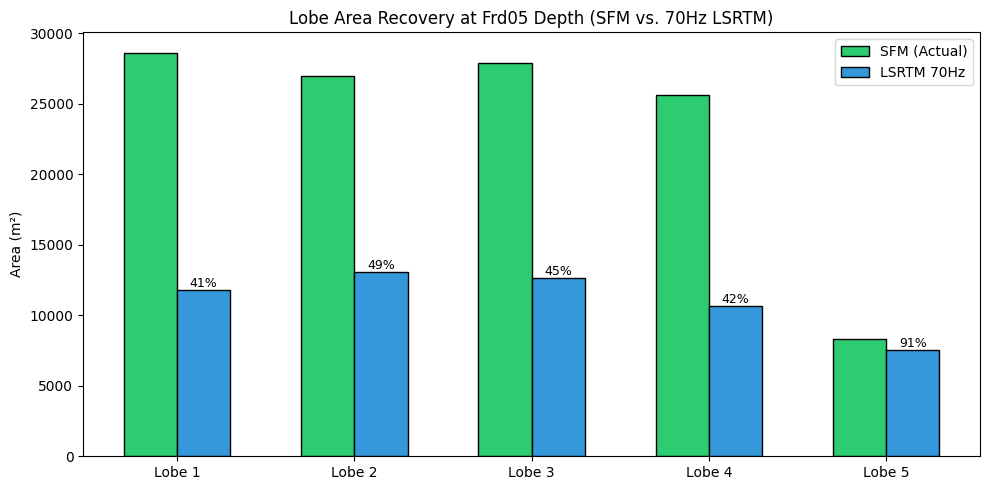

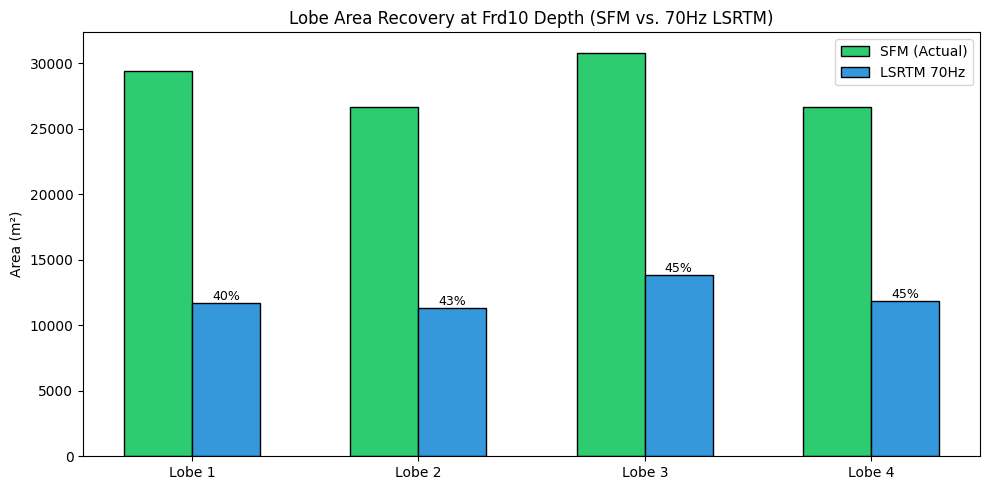

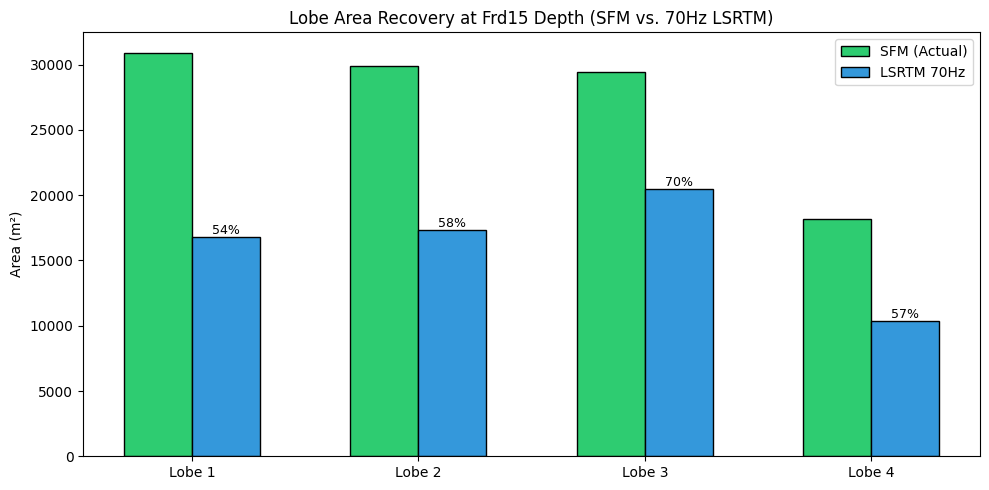

In [12]:
plot_recovery_comparison(depth='Frd05')
plot_recovery_comparison(depth='Frd10')
plot_recovery_comparison(depth='Frd15')

In [1]:
#import numpy as np
#import matplotlib.pyplot as plt

# SFM ground truth (width [m], height [m])
sfm_metrics = {
    'Frd05': {
        'width': [3148.41, 3221.03, 3033.07, 3571.33, 2240.62],  # Lobe 1-5
        'height': [21, 18, 18, 15, 9] # [15, 13, 14, 10, 8]
    },
    'Frd10': {
        'width': [3101.57, 3775.24, 5402.80, 3026.72],  # Same as shallow (+1050m)
        'height': [21, 18, 15, 17] # [15, 12, 10, 11]
    },

    'Frd15': {
        'width': [3114.89, 3123.40, 3891.48, 4397.87],  # Same as shallow (+1050m)
        'height': [21, 18, 15, 12] # [16, 14, 11, 10]
    }
}

# LSRTM recovered metrics (width [m], height [m])
lsrtm_metrics = {
    'Frd05': {
        '70Hz': {'width': [1869.78, 2094.94, 2016.63, 1693.57, 1331.36], 'height': [15.39, 15.28, 15.35, 15.38, 13.90]}
        #'50Hz': {'width': [1304, 1127, 1296, 1533, 1149], 'height': [10.97, 11.92, 12.31, 12.62, 12.58]},
        #'30Hz': {'width': [1054, 1046, 1046, 1466, 1018], 'height': [13.24, 14.81, 14.81, 15.11, 15.11]}
    },
    'Frd10': {
        '70Hz': {'width': [1494.31, 1412.21, 1732.42, 1658.52], 'height': [16.05, 16.48, 16.36, 14.78]}
        #'50Hz': {'width': [1289.473, 1326.315, 1311.578, 1657.894, 1223.157], 'height': [10.90, 11.18, 11.11, 10.92, 10.55]},
        #'30Hz': {'width': [1215, 1116, 1116, 1478, 1027], 'height': [12.04, 14.31, 14.31, 14.35, 14.35]}
    },

    'Frd15': {
        '70Hz': {'width': [2004.63, 2084.52, 2476.73, 1205.68], 'height': [15.24, 15.13, 15.04, 15.65]}
        #'50Hz': {'width': [1289.473, 1326.315, 1311.578, 1657.894, 1223.157], 'height': [10.90, 11.18, 11.11, 10.92, 10.55]},
        #'30Hz': {'width': [1215, 1116, 1116, 1478, 1027], 'height': [12.04, 14.31, 14.31, 14.35, 14.35]}
    }
}

def plot_width_comparison(depth='Frd05'):
    n_lobes = len(sfm_metrics[depth]['width'])
    lobes = [f'Lobe {i+1}' for i in range(n_lobes)]
    x = np.arange(n_lobes)
    width = 0.3

    fig, ax = plt.subplots(figsize=(10, 5))

    # Plot SFM (ground truth)
    sf = ax.bar(x - width/2, sfm_metrics[depth]['width'], width,
                label='SFM (Actual)', color='#2ecc71', edgecolor='black')

    # Plot LSRTM 70Hz
    b70 = ax.bar(x + width/2, lsrtm_metrics[depth]['70Hz']['width'], width,
                 label='LSRTM 70Hz', color='#3498db', edgecolor='black')

    # Annotate percentage recovery
    for i in range(n_lobes):
        sfm_val = sfm_metrics[depth]['width'][i]
        ls_val = lsrtm_metrics[depth]['70Hz']['width'][i]
        if not np.isnan(ls_val):
            pct = ls_val / sfm_val * 100
            ax.text(x[i] + width/2, ls_val, f'{pct:.0f}%', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(lobes)
    ax.set_ylabel('Width (m)')
    ax.set_title(f'Lobe Width Recovery at {depth} Depth (SFM vs. 70Hz LSRTM)')
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_height_comparison(depth='Frd05'):
    n_lobes = len(sfm_metrics[depth]['height'])
    lobes = [f'Lobe {i+1}' for i in range(n_lobes)]
    x = np.arange(n_lobes)
    width = 0.3

    fig, ax = plt.subplots(figsize=(10, 5))

    # Plot SFM (ground truth)
    sf = ax.bar(x - width/2, sfm_metrics[depth]['height'], width,
                label='SFM (Actual)', color='#2ecc71', edgecolor='black')

    # Plot LSRTM 70Hz
    b70 = ax.bar(x + width/2, lsrtm_metrics[depth]['70Hz']['height'], width,
                 label='LSRTM 70Hz', color='#3498db', edgecolor='black')

    # Annotate percentage recovery
    for i in range(n_lobes):
        sfm_val = sfm_metrics[depth]['height'][i]
        ls_val = lsrtm_metrics[depth]['70Hz']['height'][i]
        if not np.isnan(ls_val):
            pct = ls_val / sfm_val * 100
            ax.text(x[i] + width/2, ls_val, f'{pct:.0f}%', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(lobes)
    ax.set_ylabel('Height (m)')
    ax.set_title(f'Lobe Height Recovery at {depth} Depth (SFM vs. 70Hz LSRTM)')
    ax.legend()
    plt.tight_layout()
    plt.show()


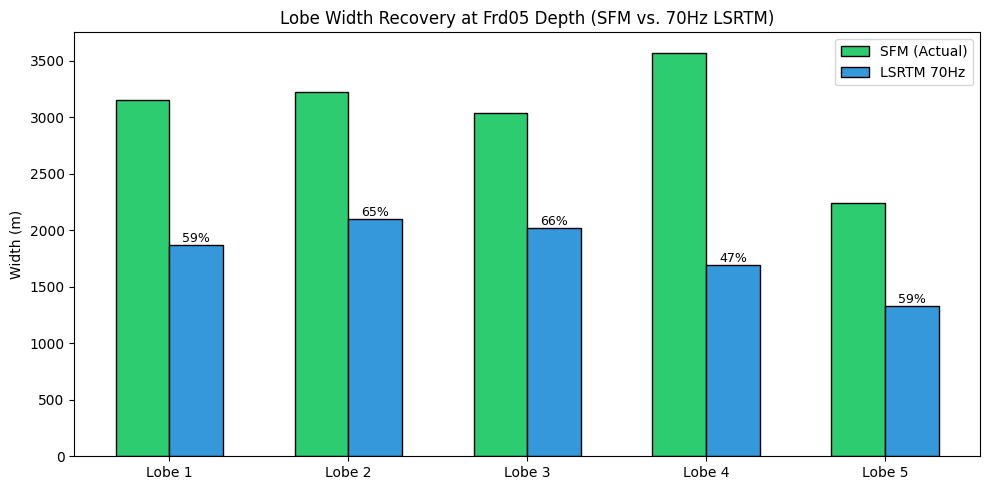

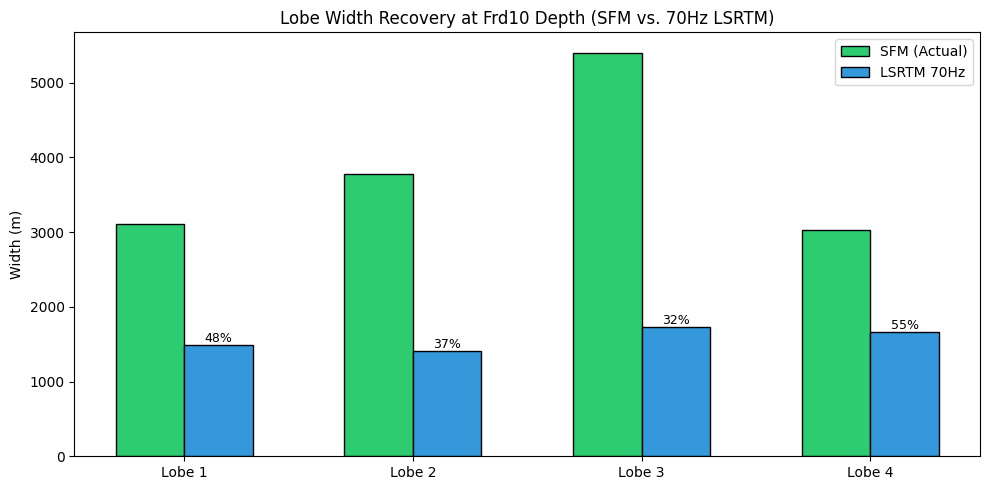

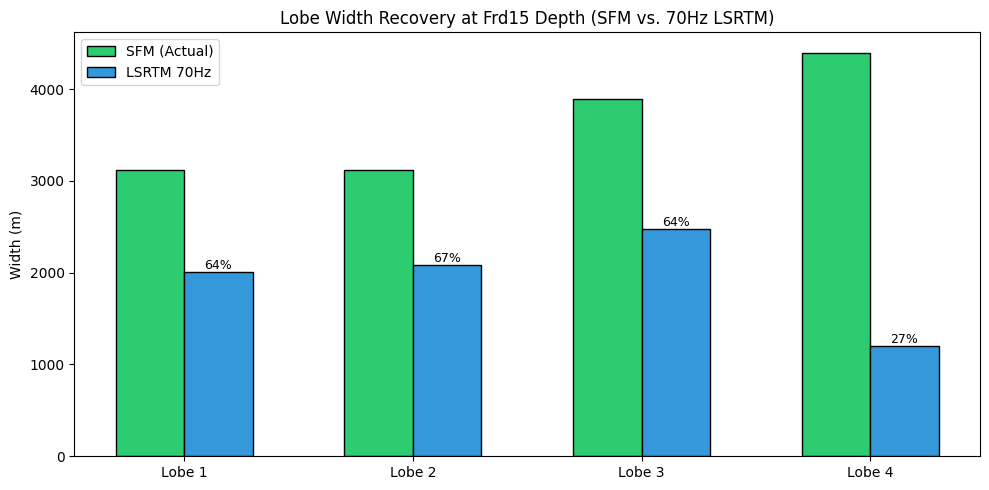

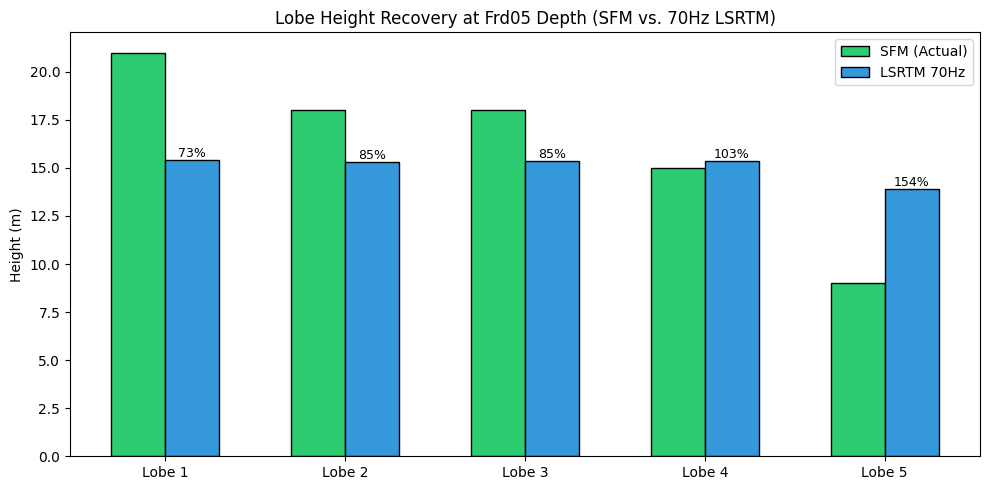

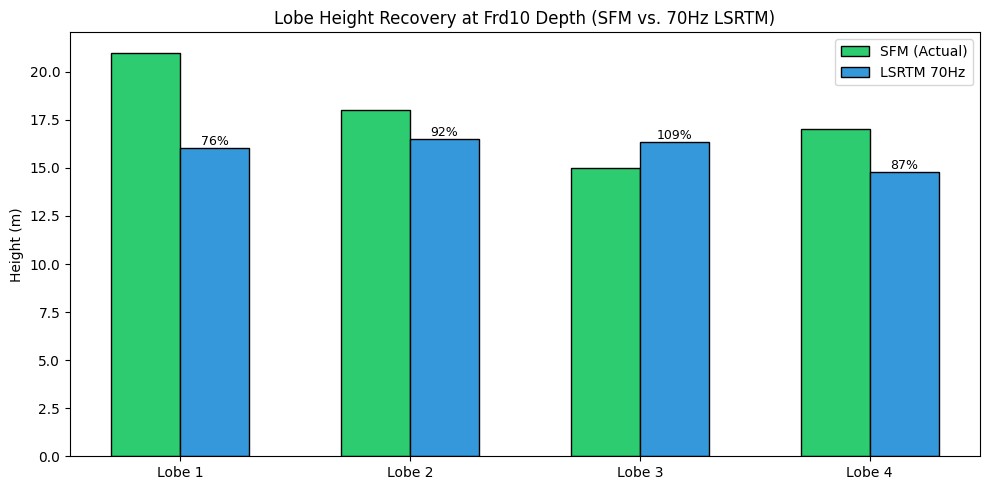

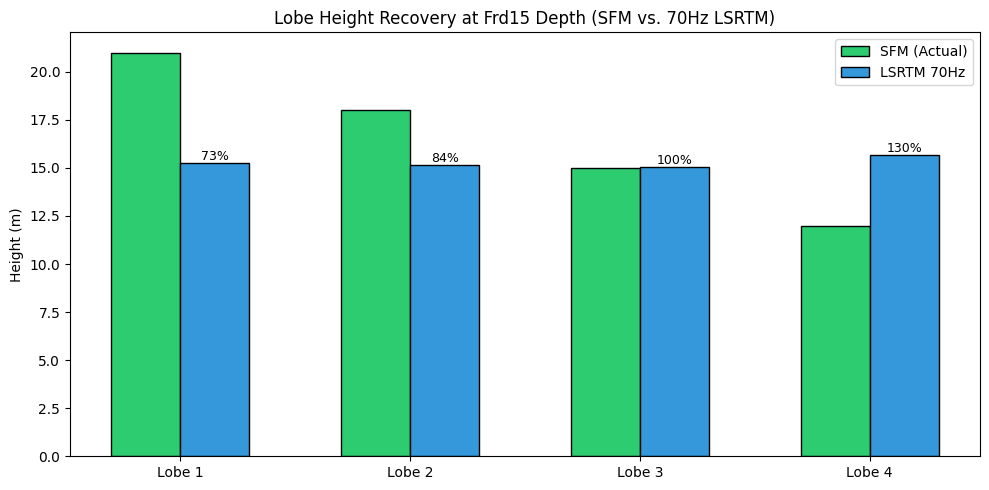

In [4]:
plot_width_comparison(depth='Frd05')
plot_width_comparison(depth='Frd10')
plot_width_comparison(depth='Frd15')
plot_height_comparison(depth='Frd05')
plot_height_comparison(depth='Frd10')
plot_height_comparison(depth='Frd15')